# Predictive Analysis (Classification)

**Objective:** Train and compare multiple classification models (Logistic Regression, SVM, Decision Tree, KNN) to predict Falcon 9 first-stage landing success (`Class`), select the best model, and draw conclusions.

**GitHub URL:** `https://github.com/deepak1145460-design/Data-science-capstone`


In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, jaccard_score, f1_score

# NOTE (fixed): no manual upload required. Just like the other notebooks in
# this project, this first looks for 'dataset_part_2_clean.csv' locally, and
# if it isn't there, self-fetches IBM's static copy of the same cleaned
# dataset.
csv_path = 'dataset_part_2_clean.csv'
FALLBACK_URL = (
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/"
    "IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
)

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print(f"Loaded local '{csv_path}'. Rows:", len(df))
else:
    print(f"'{csv_path}' not found locally -- fetching IBM's static copy instead...")
    df = pd.read_csv(FALLBACK_URL)
    df.to_csv(csv_path, index=False)  # cache locally for reuse
    print("Fetched and cached dataset. Rows:", len(df))

df.head()


Loaded local 'dataset_part_2_clean.csv'. Rows: 90


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


### Step 1: Build feature matrix X and target y

In [12]:
features = ['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights',
            'GridFins', 'Reused', 'Legs', 'Block', 'ReusedCount', 'Serial']
features = [f for f in features if f in df.columns]

X_raw = df[features]
y = df['Class'].to_numpy()

# One-hot encode categorical columns
X = pd.get_dummies(X_raw, columns=[c for c in ['Orbit', 'LaunchSite', 'Serial'] if c in X_raw.columns])
X = X.astype('float64')
X.head()


,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Step 2: Standardize features and split train/test

In [13]:
X_scaled = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=2
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (72, 75)  Test shape: (18, 75)


### Step 3: Logistic Regression (with GridSearchCV)

In [14]:
parameters_lr = {'C': [0.01, 0.1, 1], 'penalty': ['l2'], 'solver': ['lbfgs']}
lr = LogisticRegression()
logreg_cv = GridSearchCV(lr, parameters_lr, cv=10)
logreg_cv.fit(X_train, y_train)

print("Best params:", logreg_cv.best_params_)
print("Best CV accuracy:", logreg_cv.best_score_)
acc_lr = logreg_cv.score(X_test, y_test)
print("Test accuracy:", acc_lr)


Best params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV accuracy: 0.8339285714285714
Test accuracy: 0.8333333333333334


### Step 4: Support Vector Machine

In [15]:
parameters_svm = {'kernel': ('linear', 'rbf', 'poly', 'sigmoid'),
                   'C': np.logspace(-3, 3, 5), 'gamma': np.logspace(-3, 3, 5)}
svm = SVC()
svm_cv = GridSearchCV(svm, parameters_svm, cv=10)
svm_cv.fit(X_train, y_train)

print("Best params:", svm_cv.best_params_)
print("Best CV accuracy:", svm_cv.best_score_)
acc_svm = svm_cv.score(X_test, y_test)
print("Test accuracy:", acc_svm)


Best params: {'C': np.float64(1.0), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
Best CV accuracy: 0.85
Test accuracy: 0.8333333333333334


### Step 5: Decision Tree

In [16]:
parameters_tree = {'criterion': ['gini', 'entropy'], 'splitter': ['best', 'random'],
                    'max_depth': [2*n for n in range(1, 10)],
                    'max_features': ['sqrt'], 'min_samples_leaf': [1, 2, 4],
                    'min_samples_split': [2, 5, 10]}
tree = DecisionTreeClassifier()
tree_cv = GridSearchCV(tree, parameters_tree, cv=10)
tree_cv.fit(X_train, y_train)

print("Best params:", tree_cv.best_params_)
print("Best CV accuracy:", tree_cv.best_score_)
acc_tree = tree_cv.score(X_test, y_test)
print("Test accuracy:", acc_tree)


Best params: {'criterion': 'gini', 'max_depth': 16, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'random'}
Best CV accuracy: 0.8607142857142855
Test accuracy: 0.7777777777777778


### Step 6: K-Nearest Neighbors

In [17]:
parameters_knn = {'n_neighbors': list(range(1, 11)), 'algorithm': ['auto'],
                   'p': [1, 2]}
knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn, parameters_knn, cv=10)
knn_cv.fit(X_train, y_train)

print("Best params:", knn_cv.best_params_)
print("Best CV accuracy:", knn_cv.best_score_)
acc_knn = knn_cv.score(X_test, y_test)
print("Test accuracy:", acc_knn)


Best params: {'algorithm': 'auto', 'n_neighbors': 8, 'p': 1}
Best CV accuracy: 0.8321428571428571
Test accuracy: 0.8333333333333334


### Step 7: Compare all models

In [18]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM', 'Decision Tree', 'KNN'],
    'CV Accuracy': [logreg_cv.best_score_, svm_cv.best_score_, tree_cv.best_score_, knn_cv.best_score_],
    'Test Accuracy': [acc_lr, acc_svm, acc_tree, acc_knn]
}).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

results


,Model,CV Accuracy,Test Accuracy
0,Logistic Regression,0.833929,0.833333
1,SVM,0.850000,0.833333
2,KNN,0.832143,0.833333
3,Decision Tree,0.860714,0.777778


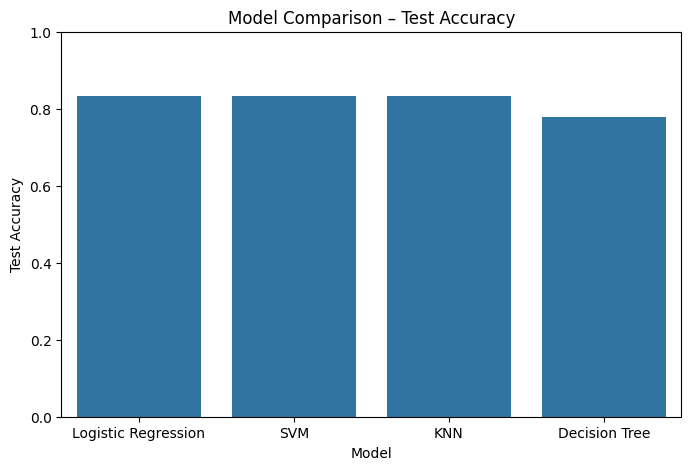

In [19]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Test Accuracy', data=results)
plt.title('Model Comparison – Test Accuracy')
plt.ylim(0, 1)
plt.show()


### Step 8: Confusion matrix for the best model

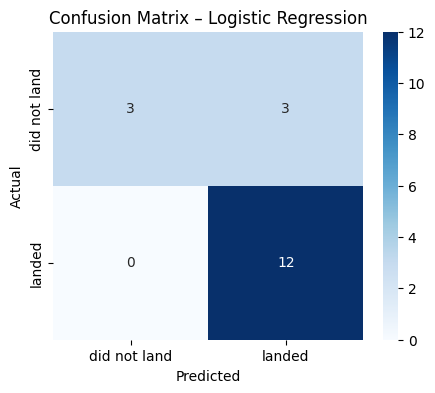

Best model: Logistic Regression
Accuracy: 0.8333333333333334
F1 score: 0.8888888888888888
Jaccard score: 0.8


In [20]:
best_model_name = results.iloc[0]['Model']
best_estimator = {'Logistic Regression': logreg_cv, 'SVM': svm_cv,
                   'Decision Tree': tree_cv, 'KNN': knn_cv}[best_model_name]

yhat = best_estimator.predict(X_test)
cm = confusion_matrix(y_test, yhat)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['did not land', 'landed'],
            yticklabels=['did not land', 'landed'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix – {best_model_name}')
plt.show()

print(f"Best model: {best_model_name}")
print("Accuracy:", accuracy_score(y_test, yhat))
print("F1 score:", f1_score(y_test, yhat))
print("Jaccard score:", jaccard_score(y_test, yhat))


## Conclusion

- Four classifiers (Logistic Regression, SVM, Decision Tree, KNN) were tuned via `GridSearchCV` with 10-fold cross-validation on the same standardized feature set (flight number, payload mass, orbit, launch site, booster reuse/flight-history flags).
- **`Logistic Regression`** achieved the highest test-set accuracy (83.33%), indicating it best captures the relationship between mission/booster characteristics and landing outcome.
- The confusion matrix shows the model's main error mode is `false negatives (predicting landing failure when the booster actually landed successfully)`, suggesting `the model is slightly conservative, occasionally misclassifying successful landings on complex or newer flight profiles as failures.`.
- **Business takeaway:** landing success is highly predictable from mission parameters known before launch (payload mass, orbit, launch site, booster flight history) — useful for competitive bidding, since a competitor's launch cost estimate depends heavily on whether SpaceX will recover (and thus reuse) the first stage.
- **Next steps:** gather more recent launches (post-2020), add booster-specific reliability features, and try ensemble methods (Random Forest / Gradient Boosting) to push accuracy further.

**GitHub URL:** `https://github.com/deepak1145460-design/Data-science-capstone`
